# Advanced Techniques (2): Domain Feature Engineering

In Tutorial 1 we built a stronger baseline by comparing simple feature candidates such as `BMI`, `School_CE`, and missing-value indicators.

Here we go one step further and create **domain features** from the NFL Combine measurements — the sprint, jumps, and agility drills introduced in Tutorial 1. The goal is not to add features blindly, but to use knowledge about athletic performance to form hypotheses, turn them into interpretable features, and check whether they improve cross-validated ROC-AUC. "Domain knowledge" here is just what you understand about athletes, so if American football is unfamiliar, lean on a sport you do know.

As in Tutorial 1, the engineered features are *evidence* to be tested, not a finished answer — a feature stays only if validation says it helps.

The workflow is the same as Tutorial 1:

> Form a hypothesis → create a feature → evaluate with cross-validation → compare the results → decide whether to keep it

**Task**: Predict the probability that an NFL prospect is **Drafted**. `1` means the player was drafted, and `0` means the player was not drafted.  
**Evaluation metric**: ROC-AUC.

## Connection to Previous Lectures

In this notebook, we apply ideas from the previous lectures to a competition-style feature engineering workflow.

- From **Feature Engineering**, we create new features from existing columns.
- From **Model Evaluation**, we check whether those features improve ROC-AUC.
- From **Cross-Validation**, we evaluate each feature idea under the same validation setting.
- From **Supervised Learning**, we keep the modeling setup simple so that the effect of the features is easier to interpret.

## Contents

1. Setup
2. Load the data
3. Understand the data
4. Preprocessing
5. Domain feature engineering
6. Compare engineered features
7. Feature importance
8. Create the submission file
9. Wrap-up

## 1. Setup

### 1.1 Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

### 1.2 Connect with Google Drive

In [3]:
# If you are using Google Colaboratory, run this cell as well.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Next, move to the folder that contains this notebook and the `input/` folder.

In [7]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"


/content/drive/MyDrive/competition2026Apr


Run the cell below to check the path is correct.

In [8]:
from pathlib import Path

WORK_DIR = Path.cwd()
PATH = WORK_DIR / 'input'
train_file = PATH / 'train.csv'
test_file = PATH / 'test.csv'
sample_sub_file = PATH / 'sample_submission.csv'

if train_file.exists() and test_file.exists() and sample_sub_file.exists():
    print('All required files exist and the path is set correctly.')
else:
    print('Some files are missing or the path is not set correctly.')

All required files exist and the path is set correctly.


## 2. Load the data

**IMPORTANT:** Whenever you change a feature, a preprocessing step, or a model, re-run **every cell from this data-loading cell downward** so that `train_raw` and `test_raw` are rebuilt from the original files. Many strange errors come from a stale DataFrame left over from a previous run.

In [9]:
train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
sample_sub = pd.read_csv(sample_sub_file)

# We keep raw copies so that preprocessing can always start from the same data.
train_raw = train.copy()
test_raw = test.copy()

print(f'train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}')

train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


In [10]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

## 3. Understand the data

We do not repeat Tutorial 1's full EDA. We look at the combine measurements with one question in mind: how could each be turned into a more useful feature? For each column, ask what it measures, which direction is better, whether it depends on body size, and whether related drills could be combined.

### 3.1 Missing values

In [12]:
missing_summary = (
    train_raw
    .isna()
    .sum()
    .to_frame('missing_count')
)

missing_summary['missing_rate'] = missing_summary['missing_count'] / len(train_raw)
missing_summary.sort_values('missing_rate', ascending=False)

,missing_count,missing_rate
Agility_3cone,970,0.348795
Shuttle,912,0.327940
Bench_Press_Reps,721,0.259259
Broad_Jump,581,0.208918
Vertical_Jump,554,0.199209
Age,435,0.156419
Sprint_40yd,145,0.052140
Id,0,0.000000
Height,0,0.000000
Weight,0,0.000000


**Findings:**
- The combine drills still carry many missing values, as in the previous tutorial.
- Any statistic used to fill them (a mean, a median) has to be learned from the training rows only.

### 3.2 Numeric combine measurements

In [13]:
combine_cols = [
    'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'
]

train_raw[combine_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Height,2781.0,1.873590,0.067178,1.651000,1.828800,1.879600,1.930400,2.082800
Weight,2781.0,109.502026,20.307239,67.585263,92.986436,104.779837,124.284309,162.386068
Sprint_40yd,2636.0,4.764818,0.299343,4.220000,4.530000,4.680000,4.950000,6.000000
Vertical_Jump,2227.0,83.506349,10.710691,44.450000,76.200000,83.820000,91.440000,114.300000
Bench_Press_Reps,2060.0,20.236408,6.410662,2.000000,16.000000,20.000000,24.000000,45.000000
Broad_Jump,2200.0,291.985700,23.924666,198.120000,276.860000,294.640000,307.340000,373.380000
Agility_3cone,1811.0,7.230447,0.410686,6.280000,6.930000,7.130000,7.490000,9.040000
Shuttle,1869.0,4.399422,0.263851,3.820000,4.200000,4.350000,4.560000,5.560000


These columns measure different things, and not all point the same way:

- `Height`, `Weight` — body size.
- `Sprint_40yd` — speed, but a *time*, so lower is better.
- `Vertical_Jump`, `Broad_Jump` — lower-body explosiveness (higher is better).
- `Agility_3cone`, `Shuttle` — timed agility drills, so lower is better.
- `Bench_Press_Reps` — strength.
- They also sit on very different numeric scales — which matters once we start combining them.

### 3.3 Relationships between combine measurements

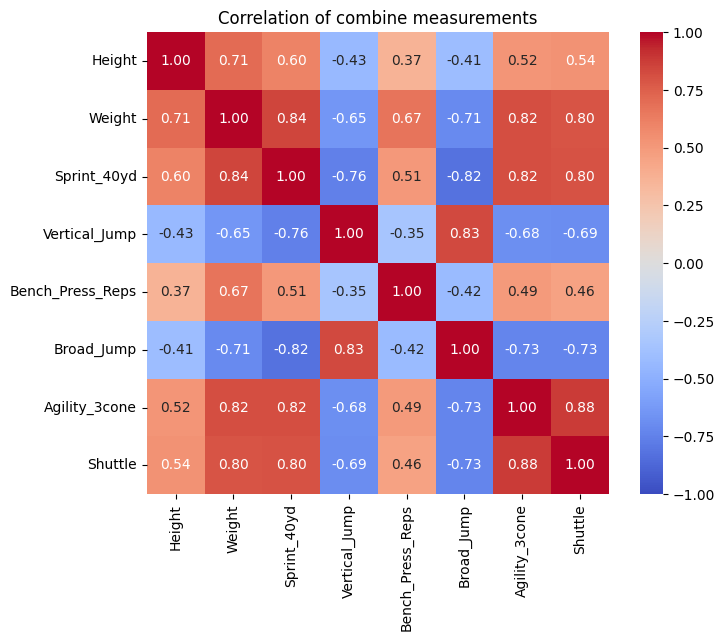

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    train_raw[combine_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title('Correlation of combine measurements')
plt.show()

**Findings:**
- `Vertical_Jump` and `Broad_Jump` move together — both are lower-body explosiveness.
- `Agility_3cone` and `Shuttle` move together — both are change-of-direction drills.

**Questions to think about:**
- Which pairs of drills look redundant enough that one combined feature could stand in for both?
- Two drills on different scales: what has to happen before you average them so one does not dominate?
- Which measurements depend on body size, and would be more meaningful once size-adjusted?

## 4. Preprocessing

We use the same basic preprocessing ideas as Tutorial 1.

The base feature set in this notebook includes the simple feature candidates from Tutorial 1:

- `BMI`
- `School_CE`
- missing-value indicators

Then, in Section 5, we add new domain features on top of this base.

### 4.1 Define preprocessing constants

In [15]:
TARGET = 'Drafted'
ID_COL = 'Id'
HIGH_CARDINALITY_COL = 'School'

NUMERIC_MISSING_COLS = [
    'Age',
    'Sprint_40yd',
    'Vertical_Jump',
    'Bench_Press_Reps',
    'Broad_Jump',
    'Agility_3cone',
    'Shuttle',
]

CATEGORICAL_COLS = ['Player_Type', 'Position_Type', 'Position']

### 4.2 Base preprocessing

The cell below applies base preprocessing directly, starting from `train_raw` and `test_raw`.

It:
1. Creates `BMI` from `Height` and `Weight`.
2. Applies count encoding to `School`.
3. Creates missing-value indicators **before** imputation — once a gap is filled with the training mean, the missingness information is lost.
4. Fills missing numeric values with the **training** mean (applied to both train and test to avoid leakage).
5. Label-encodes low-cardinality categorical columns; unseen test categories get `-1`.

Domain features (`SPEED_SCORE`, `EXPLOSIVENESS`, `AGILITY_RATIO`) are added inline in Section 5.

In [16]:
train = train_raw.copy()
test  = test_raw.copy()

# BMI
train['BMI'] = train['Weight'] / (train['Height'] ** 2)
test['BMI']  = test['Weight']  / (test['Height']  ** 2)

# School Count Encoding
school_counts = train[HIGH_CARDINALITY_COL].value_counts()
train['School_CE'] = train[HIGH_CARDINALITY_COL].map(school_counts).fillna(0)
test['School_CE']  = test[HIGH_CARDINALITY_COL].map(school_counts).fillna(0)

# Missing indicators (created before imputation)
for c in NUMERIC_MISSING_COLS:
    train[f'{c}_missing'] = train[c].isna().astype(int)
    test[f'{c}_missing']  = test[c].isna().astype(int)

# Mean imputation
for c in NUMERIC_MISSING_COLS:
    mean_value = train[c].mean()
    train[c] = train[c].fillna(mean_value)
    test[c]  = test[c].fillna(mean_value)

# Label encoding for low-cardinality categorical columns
for c in CATEGORICAL_COLS:
    categories = train[c].astype(str).unique()
    mapping = {cat: i for i, cat in enumerate(categories)}
    train[c] = train[c].astype(str).map(mapping).astype(int)
    test[c]  = test[c].astype(str).map(mapping).fillna(-1).astype(int)

print('Base preprocessing done.')
print(f'train shape: {train.shape}, test shape: {test.shape}')

Base preprocessing done.
train shape: (2781, 25), test shape: (696, 24)


### 4.3 Cross-validation helpers

As in Tutorial 1, we use 5-fold Stratified Cross-Validation.

`cv_fit_predict` returns OOF predictions and fold-averaged test predictions without any resampling.

`cv_fit_predict_smote` — defined below — applies SMOTE only inside each training fold. Because the validation fold is never oversampled, OOF AUC reflects the original class distribution. See Section 5.4 for details on when to use it.

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def cv_fit_predict(make_model, X, y, X_test=None):
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test)) if X_test is not None else None
    fold_aucs = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = make_model()
        model.fit(X_tr, y_tr)

        va_pred = model.predict_proba(X_va)[:, 1]
        oof[va_idx] = va_pred

        fold_auc = roc_auc_score(y_va, va_pred)
        fold_aucs.append(fold_auc)

        if X_test is not None:
            test_pred += model.predict_proba(X_test)[:, 1] / skf.n_splits

        print(f'Fold {fold}: AUC = {fold_auc:.4f}')

    oof_auc = roc_auc_score(y, oof)
    print(f'OOF AUC: {oof_auc:.4f}')

    return oof, test_pred, oof_auc, fold_aucs

`cv_fit_predict_smote` applies SMOTE inside each training fold only.

The validation fold is never resampled, so the OOF AUC is evaluated on the original class distribution — which gives a more honest estimate than applying SMOTE to the full training set before CV.

To use it, replace `cv_fit_predict` with `cv_fit_predict_smote` in Section 6.2.  
Requires: `pip install imbalanced-learn`.

In [18]:
def cv_fit_predict_smote(make_model, X, y, X_test=None):
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=SEED)

    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test)) if X_test is not None else None
    fold_aucs = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # SMOTE is applied only to the training fold.
        X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

        model = make_model()
        model.fit(X_tr_res, y_tr_res)

        va_pred = model.predict_proba(X_va)[:, 1]
        oof[va_idx] = va_pred

        fold_auc = roc_auc_score(y_va, va_pred)
        fold_aucs.append(fold_auc)

        if X_test is not None:
            test_pred += model.predict_proba(X_test)[:, 1] / skf.n_splits

        print(f'Fold {fold}: AUC = {fold_auc:.4f}')

    oof_auc = roc_auc_score(y, oof)
    print(f'OOF AUC: {oof_auc:.4f}')

    return oof, test_pred, oof_auc, fold_aucs

**Questions to think about:**
- `AGILITY_RATIO` is filled with the train median when a drill is missing. Why is a *ratio* especially fragile when one of its inputs is absent?
- Are the missing-value indicators from Tutorial 1 still pulling their weight now that domain features exist?

## 5. Domain feature engineering

Now we use domain knowledge to build features from the athletic measurements. A useful domain feature has a clear interpretation, respects the direction of its inputs (lower `Sprint_40yd` is better, higher `Vertical_Jump` is better), and earns its place only if it improves CV.

If American football is unfamiliar, anchor this in a sport you do know: which *combination* of measurements marks out a strong athlete there — size paired with speed, two kinds of jump, a balance between drills? The three features below are exactly that kind of combination — `SPEED_SCORE`, `EXPLOSIVENESS`, and `AGILITY_RATIO` — each a different hypothesis.

### 5.1 `SPEED_SCORE`

`Sprint_40yd` is a time — lower is better — and a model can already use it directly. But speed may be more telling combined with size: a heavy player running a fast 40 is more notable than a light one at the same time. That hypothesis motivates combining `Weight` and `Sprint_40yd`:

`SPEED_SCORE = (Weight * 200) / (Sprint_40yd ** 4)`

For example, two prospects both run 4.5 s, but one weighs 110 kg and the other 90 kg: the formula gives the heavier one ≈ 53.7 and the lighter one ≈ 43.9, rewarding speed carried at size. The constant and the exponent are not sacred; the idea is what matters:

> Speed adjusted for body size may carry more information than sprint time alone.

In [19]:
train['SPEED_SCORE'] = (train['Weight'] * 200.0) / (train['Sprint_40yd'] ** 4)
test['SPEED_SCORE']  = (test['Weight']  * 200.0) / (test['Sprint_40yd']  ** 4)

train['SPEED_SCORE'].describe()

,SPEED_SCORE
count,2781.000000
mean,42.500155
std,5.761241
min,20.999647
25%,38.811715
50%,42.771977
75%,46.477666
max,60.466453


### 5.2 `EXPLOSIVENESS`

`Vertical_Jump` (upward) and `Broad_Jump` (horizontal) both measure lower-body explosiveness, and a player strong in both probably has more of it. Because the two are on different scales, we standardize each with the *training* mean and standard deviation before averaging:

`EXPLOSIVENESS = mean(z(Vertical_Jump), z(Broad_Jump))`

One feature now summarizes two related drills.

In [20]:
vj_mean = train['Vertical_Jump'].mean()
vj_std  = train['Vertical_Jump'].std()
bj_mean = train['Broad_Jump'].mean()
bj_std  = train['Broad_Jump'].std()

train['EXPLOSIVENESS'] = 0.5 * (
    (train['Vertical_Jump'] - vj_mean) / vj_std
    + (train['Broad_Jump']  - bj_mean) / bj_std
)
test['EXPLOSIVENESS'] = 0.5 * (
    (test['Vertical_Jump'] - vj_mean) / vj_std
    + (test['Broad_Jump']  - bj_mean) / bj_std
)

train['EXPLOSIVENESS'].describe()

,EXPLOSIVENESS
count,2.781000e+03
mean,-5.480454e-16
std,9.508288e-01
min,-3.885089e+00
25%,-4.184565e-01
50%,0.000000e+00
75%,5.693552e-01
max,3.452835e+00


### 5.3 `AGILITY_RATIO`

`Agility_3cone` and `Shuttle` are both change-of-direction times (lower is better). Rather than use them only as separate columns, we compare them to each other:

`AGILITY_RATIO = Agility_3cone / Shuttle`

The hypothesis is that the *balance* between the two drills says something neither does alone. A ratio is also fragile when a drill is missing — which is exactly why we let CV, not intuition, judge it.

In [21]:
train['AGILITY_RATIO'] = train['Agility_3cone'] / train['Shuttle'].where(train['Shuttle'] > 0, np.nan)
test['AGILITY_RATIO']  = test['Agility_3cone']  / test['Shuttle'].where(test['Shuttle']  > 0, np.nan)

ratio_median = train['AGILITY_RATIO'].median()
train['AGILITY_RATIO'] = train['AGILITY_RATIO'].fillna(ratio_median)
test['AGILITY_RATIO']  = test['AGILITY_RATIO'].fillna(ratio_median)

train['AGILITY_RATIO'].describe()

,AGILITY_RATIO
count,2781.000000
mean,1.644293
std,0.041982
min,1.403970
25%,1.629268
50%,1.643499
75%,1.660754
max,1.878038


**Questions to think about:**
- Each feature encodes a hypothesis. Before you run CV, predict which one will help most — then check whether you were right.
- `SPEED_SCORE` uses `Weight * 200 / Sprint_40yd**4`. How would changing the exponent affect the feature's scale and direction?
- Would normalizing a drill *within each `Position`* capture something the global feature misses?

### 5.4 Optional: SMOTE

**What SMOTE does.** SMOTE (Synthetic Minority Over-sampling Technique) handles class imbalance by generating *synthetic* minority-class samples rather than simply duplicating existing ones. For each minority-class example $x_i$, it selects $k$ nearest neighbors in feature space, then draws a new point along the segment connecting $x_i$ to a randomly chosen neighbor $x_j$:

$$x_{\text{new}} = x_i + \lambda \cdot (x_j - x_i), \quad \lambda \sim \text{Uniform}(0, 1)$$

The result is a new sample that lies *between* two real minority examples — adding variety at the decision boundary rather than repeating rows.

**Why it can help here.** This dataset is mildly imbalanced (~65% drafted vs ~35% not drafted). Even mild imbalance can cause a tree model to split conservatively near the class boundary. SMOTE gives the model more varied minority examples to learn from.

**Placement matters — two options exist:**

| Option | When applied | OOF AUC reliability |
|---|---|---|
| Pre-loop (Option 1) | Full training set before CV | Validation folds contain synthetic rows → slightly optimistic |
| Per-fold (Option 2) | Only inside each training fold | Validation reflects the original distribution → honest |

Option 2 (`cv_fit_predict_smote`, defined in Section 4.3) is the correct approach for a rigorous evaluation. Option 1 is simpler to write but can inflate the reported OOF AUC.

The cells below are commented out by default.

**Questions to think about:**
- `k_neighbors` controls how spread out synthetic samples are in feature space. What happens if it is very small (tight interpolation near existing points) or very large (long-range interpolation)?
- Domain features like `SPEED_SCORE` are nonlinear combinations of raw inputs. Would it be more principled to apply SMOTE to the *raw* features before computing domain features, rather than to the final feature matrix?
- For a tree model, does balancing the class distribution change which splits are found, or only how leaf probabilities are estimated?

In [22]:
# [Option 1] Apply SMOTE to the full training set before the comparison loop.
# Uncomment to try. Requires: pip install imbalanced-learn
#
# from imblearn.over_sampling import SMOTE
#
# DROP_SMOTE = [ID_COL, HIGH_CARDINALITY_COL, TARGET]
# smote_cols = [c for c in train.columns if c not in DROP_SMOTE]
#
# smote = SMOTE(random_state=SEED)
# X_smote, y_smote = smote.fit_resample(
#     train[smote_cols], train[TARGET].astype(int)
# )
# X_smote = pd.DataFrame(X_smote, columns=smote_cols)
# y_smote = pd.Series(y_smote, name=TARGET)
#
# print(f'Before SMOTE: {len(train)} samples  ({train[TARGET].mean():.1%} positive)')
# print(f'After  SMOTE: {len(X_smote)} samples  ({y_smote.mean():.1%} positive)')
#
# To use in the comparison loop, replace:
#   X = train[feature_cols].copy()
# with:
#   X = X_smote[feature_cols].copy()  # (and y with y_smote)

# [Option 2] Per-fold SMOTE: replace cv_fit_predict with cv_fit_predict_smote
# in the comparison loop in Section 6.2. No other code change is needed.

## 6. Compare engineered features

Same discipline as Tutorial 1: one model, one CV split, one feature change at a time. We compare the base set, each domain feature alone, and all three together — which shows both whether a feature helps on its own and whether the three interfere when combined.

### 6.1 Fixed model for feature comparison

In [23]:
from sklearn.ensemble import RandomForestClassifier


def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=SEED,
        n_jobs=-1,
    )

### 6.2 Run the comparison

Each feature set runs through the same Random Forest and the same 5-fold CV. Treat tiny decimal differences with suspicion — a *stable* improvement is the signal worth acting on.

In [24]:
y = train[TARGET].astype(int)

DROP_COLS   = [ID_COL, HIGH_CARDINALITY_COL, TARGET]
DOMAIN_COLS = ['SPEED_SCORE', 'EXPLOSIVENESS', 'AGILITY_RATIO']
base_cols   = [c for c in train.columns if c not in DROP_COLS + DOMAIN_COLS]

feature_configs = [
    ('Base from Tutorial 1',       base_cols),
    ('Base + SPEED_SCORE',         base_cols + ['SPEED_SCORE']),
    ('Base + EXPLOSIVENESS',       base_cols + ['EXPLOSIVENESS']),
    ('Base + AGILITY_RATIO',       base_cols + ['AGILITY_RATIO']),
    ('Base + all domain features', base_cols + DOMAIN_COLS),
]

feature_rows = []
prepared_features = {}

for name, feature_cols in feature_configs:
    print('\n' + '=' * 80)
    print(name)
    print('=' * 80)

    X         = train[feature_cols].copy()
    X_test_fs = test[feature_cols].copy()

    oof, test_pred, auc, fold_aucs = cv_fit_predict(
        make_rf, X, y, X_test_fs,
    )

    feature_rows.append({
        'feature_set': name,
        'n_features': len(feature_cols),
        'OOF AUC': auc,
        'fold_auc_mean': np.mean(fold_aucs),
        'fold_auc_std': np.std(fold_aucs),
    })

    prepared_features[name] = {
        'X': X,
        'y': y,
        'X_test': X_test_fs,
        'feature_cols': feature_cols,
        'test_pred': test_pred,
    }

feature_comparison = pd.DataFrame(feature_rows).sort_values('OOF AUC', ascending=False)
feature_comparison.style.format({
    'OOF AUC': '{:.4f}',
    'fold_auc_mean': '{:.4f}',
    'fold_auc_std': '{:.4f}',
})


Base from Tutorial 1
Fold 1: AUC = 0.7945
Fold 2: AUC = 0.8494
Fold 3: AUC = 0.8406
Fold 4: AUC = 0.7934
Fold 5: AUC = 0.8389
OOF AUC: 0.8225

Base + SPEED_SCORE
Fold 1: AUC = 0.8124
Fold 2: AUC = 0.8653
Fold 3: AUC = 0.8596
Fold 4: AUC = 0.7940
Fold 5: AUC = 0.8394
OOF AUC: 0.8327

Base + EXPLOSIVENESS
Fold 1: AUC = 0.7918
Fold 2: AUC = 0.8531
Fold 3: AUC = 0.8468
Fold 4: AUC = 0.7869
Fold 5: AUC = 0.8400
OOF AUC: 0.8221

Base + AGILITY_RATIO
Fold 1: AUC = 0.7880
Fold 2: AUC = 0.8497
Fold 3: AUC = 0.8481
Fold 4: AUC = 0.7900
Fold 5: AUC = 0.8391
OOF AUC: 0.8218

Base + all domain features
Fold 1: AUC = 0.8051
Fold 2: AUC = 0.8648
Fold 3: AUC = 0.8591
Fold 4: AUC = 0.7914
Fold 5: AUC = 0.8415
OOF AUC: 0.8307


,feature_set,n_features,OOF AUC,fold_auc_mean,fold_auc_std
1,Base + SPEED_SCORE,23,0.8327,0.8342,0.0273
4,Base + all domain features,25,0.8307,0.8324,0.0292
0,Base from Tutorial 1,22,0.8225,0.8233,0.0243
2,Base + EXPLOSIVENESS,23,0.8221,0.8237,0.0284
3,Base + AGILITY_RATIO,23,0.8218,0.8230,0.0280


#### How to read the feature comparison table

The best row is best only for this model, split, and seed. Read it for which simple ideas are worth carrying forward.

### 6.3 Visualize the comparison

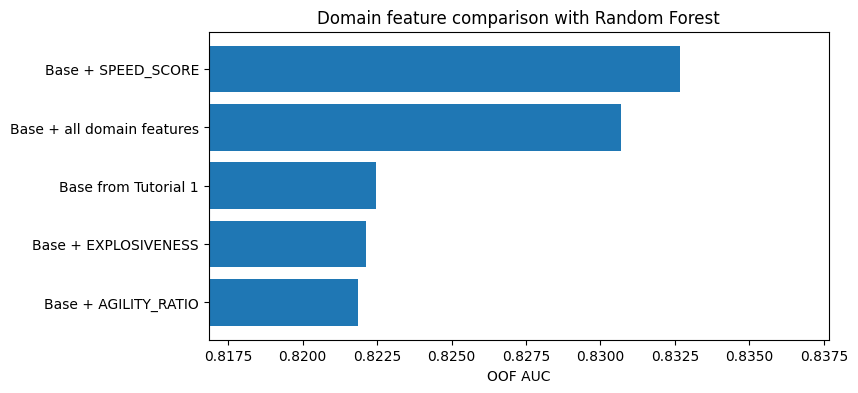

In [25]:
feature_comparison_sorted = feature_comparison.sort_values('OOF AUC', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feature_comparison_sorted['feature_set'], feature_comparison_sorted['OOF AUC'])
plt.xlabel('OOF AUC')
plt.title('Domain feature comparison with Random Forest')
plt.xlim(feature_comparison['OOF AUC'].min() - 0.005, feature_comparison['OOF AUC'].max() + 0.005)
plt.show()

### 6.4 Choose the feature set for submission

We take the feature set with the best OOF AUC. In a real workflow you would also probe whether the gain survives a different seed or model and whether the feature risks leakage; here we keep it simple and trust the comparison table.

**Questions to think about:**
- The selected set is best for Random Forest at this seed. Does it stay best under a different seed or a LightGBM model?
- If "Base + all domain features" is worse than a single added feature, which feature is adding noise?

In [26]:
selected_feature_set = feature_comparison.iloc[0]['feature_set']
print('Selected feature set:', selected_feature_set)

X = prepared_features[selected_feature_set]['X']
y = prepared_features[selected_feature_set]['y']
X_test = prepared_features[selected_feature_set]['X_test']
feature_cols = prepared_features[selected_feature_set]['feature_cols']
test_pred = prepared_features[selected_feature_set]['test_pred']

print(f'Number of selected features: {len(feature_cols)}')
print(feature_cols)

Selected feature set: Base + SPEED_SCORE
Number of selected features: 23
['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Player_Type', 'Position_Type', 'Position', 'BMI', 'School_CE', 'Age_missing', 'Sprint_40yd_missing', 'Vertical_Jump_missing', 'Bench_Press_Reps_missing', 'Broad_Jump_missing', 'Agility_3cone_missing', 'Shuttle_missing', 'SPEED_SCORE']


## 7. Feature importance

Importance shows which features *this* model leaned on — a diagnostic, not proof that a feature is causal or universally good. It is swayed by correlated features, scale, and randomness, so read it next to the CV result, not instead of it. We check whether the engineered features show up where our hypotheses predicted.

,feature,importance
15,Age_missing,0.344750
1,Age,0.133359
22,SPEED_SCORE,0.094461
4,Sprint_40yd,0.057211
13,BMI,0.044270
3,Weight,0.040437
14,School_CE,0.034035
6,Bench_Press_Reps,0.031312
8,Agility_3cone,0.030087
7,Broad_Jump,0.029334


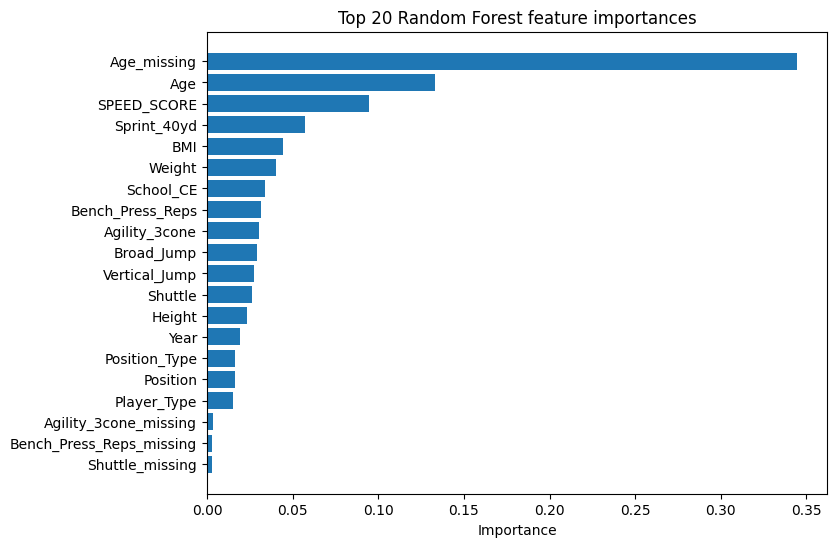

In [27]:
rf = make_rf()
rf.fit(X, y)

importance = (
    pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_,
    })
    .sort_values('importance', ascending=False)
)

display(importance.head(15))

plt.figure(figsize=(8, 6))
top_importance = importance.head(20).sort_values('importance', ascending=True)
plt.barh(top_importance['feature'], top_importance['importance'])
plt.title('Top 20 Random Forest feature importances')
plt.xlabel('Importance')
plt.show()

**Questions to think about:**
- Do the engineered features land where your hypothesis predicted in the importance ranking?
- A low-importance feature is not always useless — how could a *correlated* feature be hiding its value?

## 8. Create the submission file

We use the selected feature set from Section 6 and create `submission.csv`.

The prediction used here is the fold-averaged test prediction from the Random Forest model.

### Saving the prediction as a CSV file [DO NOT CHANGE]

**WARNING**: Do not change the following cell unless you understand what it is doing.

The final CSV must exactly match the expected format. By using `sample_submission.csv`, we preserve the required row order and column structure. Here, we replace only the `Drafted` column with our predictions.

In [28]:
submission = pd.read_csv(sample_sub_file)
submission['Drafted'] = test_pred

out_dir = WORK_DIR / 'output'
out_dir.mkdir(exist_ok=True)

submission_path = out_dir / 'submission.csv'
submission.to_csv(submission_path, index=False)

print('Saved to:', submission_path)
submission.head()

Saved to: /content/drive/MyDrive/competition2026Apr/output/submission.csv


,Id,Drafted
0,2781,0.570406
1,2782,0.770806
2,2783,0.887206
3,2784,0.886226
4,2785,0.748498


## 9. Wrap-up

In this notebook we turned domain knowledge about combine drills into a handful of interpretable features, and let cross-validation decide which ones earned their place.

The takeaway is not the three features we happened to build:

> Good feature engineering is making a hypothesis, testing it fairly, and keeping only what helps.

**Questions to think about:**
- **Tutorial 3** freezes this feature set and tunes a single model. Which hyperparameters do you expect to matter, and why?
- Would the domain features you kept here still help *after* the model is tuned?
- Try replacing `cv_fit_predict` with `cv_fit_predict_smote` in Section 6.2. Does SMOTE move the OOF AUC by more than `fold_auc_std`?

*If a cell raises an error, re-run everything from **Section 2** so the raw data is rebuilt.*